##**Zomato Restaurant Data Analysis**

Exploratory Data Analysis on Zomato dataset to uncover trends in
restaurant types, ratings, online ordering, and pricing.

 1. Importing Libraries


In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


 2. Loading the Dataset

In [32]:
df=pd.read_csv('/content/drive/MyDrive/Data Science/Machine Learning/ML Project/zomato-data.csv')

3. Data Overview

In [33]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [34]:
df.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


In [35]:
print(df.shape)
df.info()

(148, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [36]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


4. Data Cleaning

In [37]:
df[['rating','max_rating']]=df['rate'].str.split('/',expand=True)
df=df.drop('max_rating',axis=1)

df=df.drop('rate',axis=1)
df['rating']=df['rating'].astype(float)

In [38]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
votes,0
approx_cost(for two people),0
listed_in(type),0
rating,0


5. Exploratory Data Analysis (EDA)

Countplot for Restaurant Type

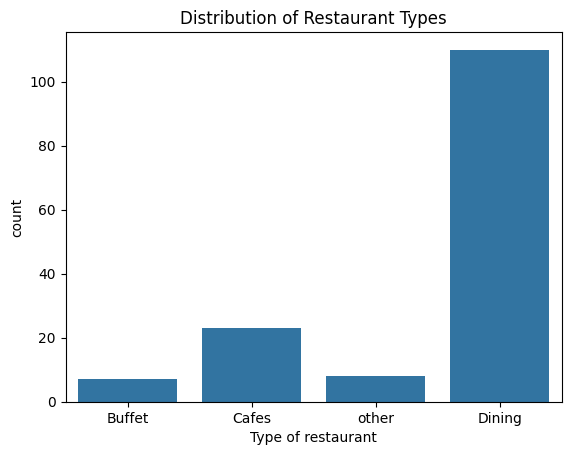

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of restaurant")
plt.title('Distribution of Restaurant Types')
plt.show()

Conclusion : The majority of the restaurants fall into the dining category

Max Votes Restaurant

In [40]:
max_votes=df['votes'].max()
restaurant_with_max_votes=df.loc[df['votes']==max_votes,'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


Countplot for Online Order


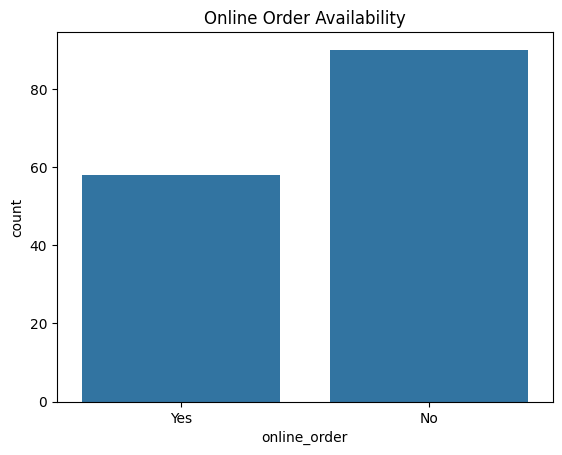

In [41]:
sns.countplot(x=df['online_order'])
plt.title('Online Order Availability')
plt.show()

Conclusion: This suggests that a majority of the restaurants do not accept online orders

Rating Distribution Histogram

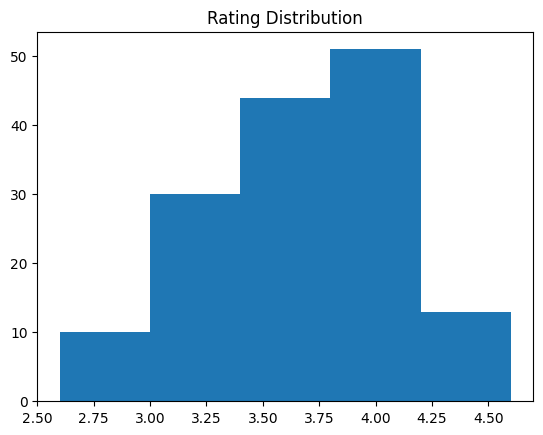

In [42]:
plt.hist(df['rating'],bins=5)
plt.title('Rating Distribution')
plt.show()

Conclusion: The majority of restaurants received ratings rangings from 3.5 to 4

Countplot for Cost


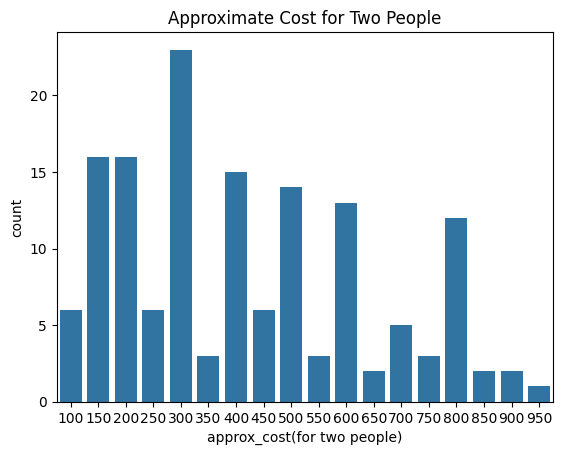

In [43]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)
plt.title('Approximate Cost for Two People')
plt.show()

Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees

Boxplot Online vs Rating

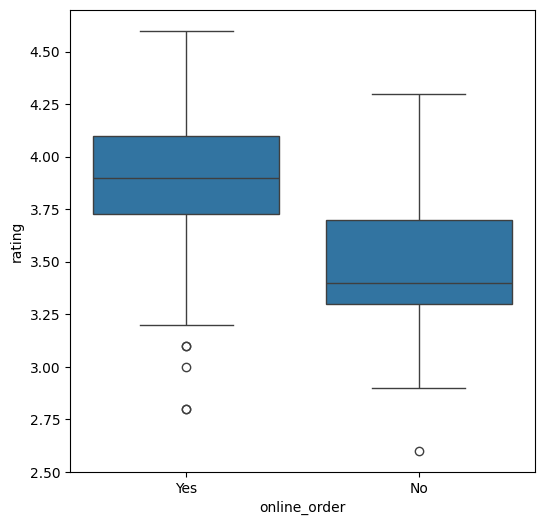

In [44]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rating',data=df)
plt.show()

Conclusion: Offline orders recieved lower ratings in comparision to online orders, which obtained excellent ratings

Heatmap

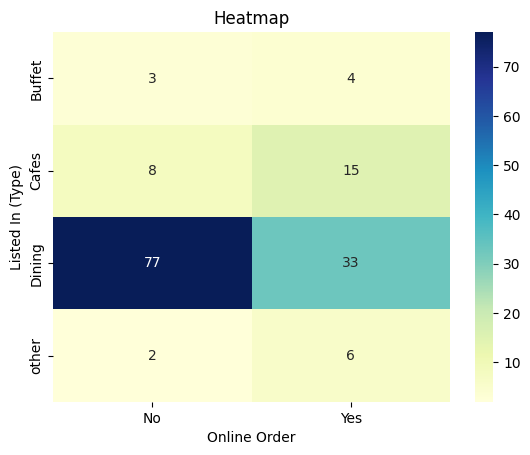

In [45]:
pivot_table=df.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

Conclusion: Dining restaurants primarily accept offline orders, whereas cafes primarily recieve online orders. This suggests that clients prefer to place orders in person at restaurants, but prefer online ordering in cafes.

**Key Findings**
- Majority of restaurants fall under the **Dining** category
- Most restaurants **do not accept online orders**
- Ratings mostly range between **3.5 to 4.0**
- Most couples prefer restaurants with a cost of around **₹300**
- Online orders tend to receive **higher ratings** than offline
- Cafes prefer **online orders**, Dining prefers **offline/in-person**
- **Empire Restaurant** has the highest number of votes